# Monday, March 23rd, 2026

Before the break, we started to discuss representing RGB images as 3D `numpy` arrays.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# RGB(s) image arrays

Recall: Most computer images are stored as arrays of RGB(A) values. We can read an image file into an RGB(A) array using `plt.imread`. The syntax is: `plt.imread(<path to some image file>)`. For example, download the image `mario.png` from the [course webpage](https://jllottes.github.io/Schedule/week_08.html) and place it into the same folder as this Jupyter notebook.

(224, 256, 4)


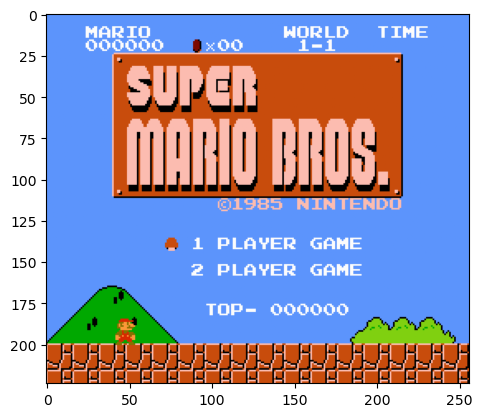

In [82]:
mario = plt.imread('mario.png')
print(mario.shape)

plt.imshow(mario)

We can look at the shape of the array to see if it contains RGB or RGBA values. In this case, the `mario.png` image file includes a transparency channel.

In [83]:
print(mario.shape)

(224, 256, 4)


**Exercise:** Use NumPy slicing to remove the transparency channel from the `mario` array.**

In [85]:
mario = mario[:, :, :3]

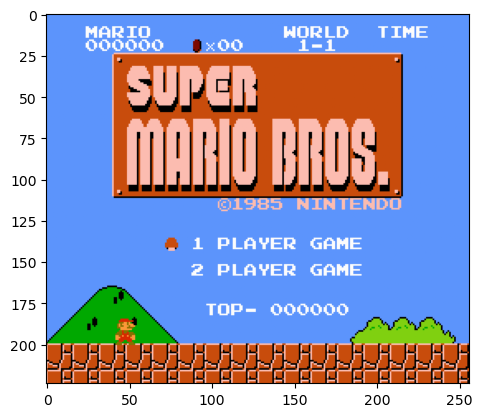

In [86]:
plt.imshow(mario)

**Exercise:** Use NumPy slicing and `plt.imshow` to zoom in on Mario (in the lower-left corner).

**Exercise:** Create an array `blueless_mario` where the blue channel information from `mario` has been removed (i.e. set to `0`) and plot using `plt.imshow`.

In [87]:
blueless_mario = mario.copy()

**Exercise:** Create an array `mixed_mario` where:
 - the red channel of `mixed_mario` matches the green channel of `mario`,
 - the green channel of `mixed_mario` matches the blue channel of `mario`,
 - the blue channel of `mixed_mario` matches the red channel of `mario`.

*Note:* For the next project, we will be working with integer-valued RGB triples. The integer-values will range from `0` to `255`. An integer `0` means no color while an integer `255` means full color (equivalent to a float of `1`).

**Exercise:** Convert the `mario` array to an integer-type array `mario_RGB_int` containing RGB triples with values between `0` and `255`.

**Exercise**: Convert the `mario_RGB_int` array into a float-type array containing RGB triples with values between `0` and `1`.

## [Project 3: Tartans](https://jllottes.github.io/Projects/tartans/tartans.html)

Let's get started working with tartans by generating vertical and horizontal stripes for the following pattern (see project page for details):

Pattern : 
> B14 K6 B6 K6 B6 K32 OG32

where the colors B, K, and OG are given by the RGB triples:

> B : [52, 80, 100]<br>
> K : [16, 16, 16]<br>
> OG : [92, 100, 40]


To get started, we'll need to initialize an array with the correct shape. What is the total width of this pattern?

Right now, our array is a pure black picture. Let's add the first vertical stripe, which has color B = [52, 80, 100] and has width 14.

**Exercise:** Add the remaining stripes from the sample pattern to the `vertical_stripes` array.

Pattern : 
> B14 K6 B6 K6 B6 K32 OG32

where the colors B, K, and OG are given by the RGB triples:

> B : [52, 80, 100]<br>
> K : [16, 16, 16]<br>
> OG : [92, 100, 40]

Some thoughts:
 - We need a much better way to generate this vertical stripes array. There was far too much manual typing/calculation to add each stripe. We'll come back and address this shortly.
 - Now that we have an array of vertical stripes, we can easily generate an array of horizontal stripes. This can be done transposing our array (see below).
 - Once we have vertical and horizontal stripes, we need to super-impose them somehow to generate the tartan pattern.

### Array transposes

For a 2-dimensional matrix, the transpose flips rows and columns. That is, the first row becomes the first column, the second row becomes the second column, etc. In Python, we can use the `.T` method on a 2D array to get its transpose:

We would like to take the transpose of our `vertical_stripes` array so that the columns of `vertical_stripes` become the rows of `horizontal_stripes`. In other words, the vertical stripes will become horizontal stripes.

*Problem:* The `vertical_stripes` array is a 3-dimensional array (rows, columns, color channels). What does `vertical_stripes.T` give us in this case?

It turns out that the `.T` attribute reverses the order of the axes. That is, the first axis (rows) becomes the last axis, the second axis (columns) becomes the second-last axis, etc. In the case of the `vertical_stripes` array, the color channel axis became the row axis, the column axis remained as the column axis, and the row axis became the color channel axis. For our needs, this is not useful. Instead, we just want to swap the row and column axes.

We can use the `np.transpose` function to do more targeted transposing:

In [1]:
#help(np.transpose)

When calling `np.transpose`, we can optionally supply a keyword argument `axes` which gives a permutation of the axes of the array. In particular, using `axes = [1, 0, 2]` will give a transposed matrix where:
 - the old axis `1` (i.e. the columns) becomes the new axis `0` (i.e. the rows),
 - the old axis `0` becomes the new axis `1`, and
 - the old axis `2` (i.e. the color channel) remains as axis `2`.

Let's use this to define the `horizontal_stripes` array.

### Creating a tartan from vertical and horizontal arrays

We now have vertical and horizontal stripes. How can we combine them to get a tartan pattern?

One simple idea is to take the average of the horizontal and vertical stripe arrays.

This gives flat colors rather than an interleaved combination. Can we instead generate a checkerboard pattern to interleave these stripes? To do so, we want to go row by row, column by column, and alternatingly select a color from the `vertical_stripes` and `horizontal_stripes` arrays.

**Exercise:** Create a `checkerboard_tartan` array that combines the `vertical_stripes` and `horizontal_stripes` arrays in checkerboard pattern.

Where to go from here:
 - We need a better way of generating the `vertical_stripes` array.
 - We need to generate the more authentic tartan pattern described in the project page.
 - We need to pad our tartan pattern to be `500` by `500` rows/columns.

### Generating the `vertical_stripes` array algorithmically

As mentioned last class, we would like to come up with a better way to generate the `vertical_stripes` array. That is, we don't want to have to manually define each stripe line-by-line, and we don't want to have to calculate appropriate slices by hand.

As a first step, let's focus on converting the given tartan pattern into something type of data that we can iterate through. 

Pattern : 
> B14 K6 B6 K6 B6 K32 OG32

where the colors B, K, and OG are given by the RGB triples:

> B : [52, 80, 100]<br>
> K : [16, 16, 16]<br>
> OG : [92, 100, 40]

Can we code this information as some sort of Python list(s)?

Can we find the total width of the pattern without manually adding the widths by hand?

With the total width calculated, we can intialize the `vertical_stripes` array that we will then fill with colored stripes.

**Exercise:** Use a `for` loop to iterate through each width/RGB pair and add the corresponding stripe to the `vertical_stripes` array.

This is a huge improvement on our previous code. Can we do better? It would be nice if we could use Python to automatically process the "recipe" to generate the lists of widths and colors. We will talk next week about how to process strings in a way that will help with this task.

We also need to tackle the following challenges for the project:
 - We need to generate the more authentic tartan pattern described in the project page.
 - We need to repeat our tartan pattern to fill a `500` by `500` image.

## Boolean NumPy arrays

A Boolean array is just a NumPy array that contains `True` and `False` values. That is, the `dtype` of the array is `Bool`. We can easily contruct Boolean arrays using Boolean expressions with arrays.

We can use logical operators on Boolean arrays:
 - `~` will negate a Boolean array (that is, `True` becomes `False` and vice-versa),
 - `&` works like `and` for two Boolean arrays, and
 - `|` works like `or` for two Boolean arrays.

### Boolean masks

One of the biggest strengths of using Boolean arrays is that they can be used as slicing tools for other arrays. For example, if `a` is an array (of any type) and `mask` is a Boolean array of the same shape, then `a[mask]` is a slice of the `a` array containing only the values where the corresponding value of `mask` is `True`.

We call this type of slicing *masking*, and the Boolean array the *mask*.

In [ ]:
a = np.arange(25).reshape(5,5)
print(a)

Suppose we want to identify the elements of the `a` array that have remainder `1` after division by `3`.

*Note: When masking, the resulting array slice is flattened into a 1D array (regardless of the shape of the original array). However, since the changes to the slice propogate back to the original array, we can make changes to this slice while preserving the layout of the data in the original array.*

For example, suppose we want to subtract `100` from each value of the `a` matrix which has remainder `1` after division by `3`.

## Back to tartans: Masking (optional)

**Exercise:** Write a function `checkerboard_mask(n)` that takes in an integer `n` and constructs an `n` by `n` Boolean array that alternates `True`/`False` everytime you move through a row or column. For example, `checkerboard_mask(6)` should return an array that looks like:
$$
\begin{bmatrix} 
\text{True} & \text{False} & \text{True} & \text{False} & \text{True} & \text{False}
\\
\text{False} & \text{True} & \text{False} & \text{True} & \text{False} & \text{True}
\\
\text{True} & \text{False} & \text{True} & \text{False} & \text{True} & \text{False}
\\
\text{False} & \text{True} & \text{False} & \text{True} & \text{False} & \text{True}
\\
\text{True} & \text{False} & \text{True} & \text{False} & \text{True} & \text{False}
\\
\text{False} & \text{True} & \text{False} & \text{True} & \text{False} & \text{True}
\end{bmatrix}$$

**Exercise:** Use a Boolean array generated by the `checkerboard_mask` function as a mask to create the checkerboard tartan pattern from the `vertical_stripes` and `horizontal_stripes` arrays.

**Exercise:** Write a function `authentic_mask(n)` that takes in an integer `n` and constructs an `n` by `n` Boolean array consisting of the sequences:
 - `[True, True, False, False, True, True, False, ...]` in the first row,
 - `[False, True, True, False, False, True, True, ...]` in the second row,
 - `[False, False, True, True, False, False, True, ...]` in the third row,
 - `[True, False, False, True, True, False, False, ...]` in the fourth row,
 - ...

For example, `authentic_mask(6)` should return an array that looks like:
$$
\begin{bmatrix} 
\text{True} & \text{True} & \text{False} & \text{False} & \text{True} & \text{True}
\\
\text{False} & \text{True} & \text{True} & \text{False} & \text{False} & \text{True}
\\
\text{False} & \text{False} & \text{True} & \text{True} & \text{False} & \text{False}
\\
\text{True} & \text{False} & \text{False} & \text{True} & \text{True} & \text{False}
\\
\text{True} & \text{True} & \text{False} & \text{False} & \text{True} & \text{True}
\\
\text{False} & \text{True} & \text{True} & \text{False} & \text{False} & \text{True}
\end{bmatrix}$$

**Exercise:** Use a Boolean array generated by the `authentic_mask` function as a mask to create the authentic tartan pattern from the `vertical_stripes` and `horizontal_stripes` arrays.